# Global Variables

In [1]:
import os
import numpy as np
import pandas as pd
import random
import torch


def reset_seeds(seed=42):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)    # 파이썬 환경변수 시드 고정
  np.random.seed(seed)
  torch.manual_seed(seed) # cpu 연산 무작위 고정
  torch.cuda.manual_seed(seed) # gpu 연산 무작위 고정
  torch.backends.cudnn.deterministic = True  # cuda 라이브러리에서 Deterministic(결정론적)으로 예측하기 (예측에 대한 불확실성 제거 )


# Load Netflix Data

In [3]:
reset_seeds() # 랜덤고정

import easydict
args = easydict.EasyDict()
from sklearn.model_selection import train_test_split


# 1. 경로 및 파일 설정 (Args 클래스)
class Args:
    def __init__(self):
        self.default_path = 'C:/dev/project/mini_project/SKN27-2nd-2TEAM/models/data/'
        

        # 넷플릭스 원본 데이터
        self.users_csv = self.default_path + 'users.csv'
        self.watch_csv = self.default_path + 'watch_history.csv'
        self.movies_csv = self.default_path + 'movies.csv'
        self.rec_logs_csv = self.default_path + 'recommendation_logs.csv'
        self.search_logs_csv = self.default_path + 'search_logs.csv'
        self.reviews_csv = self.default_path + 'reviews.csv'

        # 생성할 파일 경로
        self.train_csv = self.default_path + 'Netflix_train.csv'
        self.test_csv = self.default_path + 'Netflix_test.csv'
        self.submission_filename = 'Netflix_submission.csv'
        self.default_submission_csv = self.default_path + self.submission_filename
        self.save_results = self.default_path + 'Netflix_results.json'

args = Args()

# 2. 메인 데이터 로드 (Target인 churned가 포함된 users.csv)
user = pd.read_csv(args.users_csv)        # 'churned' 컬럼이 있다고 가정
watch = pd.read_csv(args.watch_csv)
movies = pd.read_csv(args.movies_csv)
rec_logs = pd.read_csv(args.rec_logs_csv)
search_logs = pd.read_csv(args.search_logs_csv)
reviews = pd.read_csv(args.reviews_csv)
Netflix_users = pd.read_csv(args.users_csv)

# 3. Target 변환 (Active -> Churned)
Netflix_users['is_churned'] = 1 - Netflix_users['is_active']
Netflix_users = Netflix_users.drop(columns=['is_active'])

# 데이터 분석을 위한 변수들
args.random_state = 21
args.results = []

### column
- user_id: 사용자 ID
- email: 개인정보 (학습 제외)
- first_name, last_name: 이름 (학습 제외)
- age: 사용자의 나이
- gender:	사용자의 성별
- country, state_province, city : 거주지 정보
- household_size: 가구원 수
- subscription_plan: 구독 등급
- subscription_start_date:구독 시작일
- monthly_spend: 월별 지출액
- primary_device: 주 사용 기기
- created_at: 계정 생성 일시

### Target
- is_churned: 이탈률

In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
plt.ion()

import warnings
warnings.filterwarnings('ignore')

In [13]:
ori_train = pd.read_csv(args.train_csv)
ori_test = pd.read_csv(args.test_csv)

ori_train.shape, ori_test.shape

((8240, 15), (2060, 15))

In [15]:
# 예측할 유저 수, 컬럼의 개수
pd.read_csv(args.default_submission_csv).shape

(2060, 2)

In [16]:
ori_train.columns

Index(['user_id', 'email', 'first_name', 'last_name', 'age', 'gender',
       'country', 'state_province', 'city', 'subscription_plan',
       'subscription_start_date', 'monthly_spend', 'primary_device',
       'household_size', 'created_at'],
      dtype='object')

In [ ]:
# watch에 movies 정보 먼저 붙이기
watch_movies = watch.merge(movies, on='movie_id', how='left')

# 각 테이블에서 user_id + 고유 컬럼만 선택
watch_cols = ['user_id', 'session_id', 'movie_id', 'watch_date', 'watch_duration_minutes', 
            'progress_percentage', 'action', 'quality', 'location_country', 
            'is_download', 'user_rating',
            'title', 'content_type', 'genre_primary', 'genre_secondary', 
            'release_year', 'duration_minutes', 'rating', 'language', 
            'imdb_rating', 'is_netflix_original']

rec_cols   = ['user_id', 'recommendation_id', 'movie_id', 'recommendation_date', 
            'recommendation_type', 'recommendation_score', 'was_clicked', 
            'position_in_list', 'time_of_day', 'algorithm_version']

search_cols = ['user_id', 'search_id', 'search_query', 'search_date', 
            'results_returned', 'clicked_result_position', 
            'search_duration_seconds', 'had_typo', 'used_filters', 'location_country']

review_cols = ['user_id', 'review_id', 'movie_id', 'rating', 'review_date', 
            'is_verified_watch', 'helpful_votes', 'total_votes', 
            'sentiment', 'sentiment_score']

# user 기준으로 병합
Netflix = user.copy()
for df, cols in [(watch_movies, watch_cols), 
                (rec_logs, rec_cols), 
                (search_logs, search_cols), 
                (reviews, review_cols)]:
Netflix = Netflix.merge(df[cols], on='user_id', how='left')

In [26]:
Netflix.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,location_country_y,review_id,movie_id,rating_y,review_date,is_verified_watch,helpful_votes,total_votes,sentiment,sentiment_score
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792
1,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792
2,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792
3,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792
4,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792


In [27]:
# 주요 통계치(평균, 최솟값, 최댓)
display(Netflix.describe())

,age,monthly_spend,household_size,watch_duration_minutes,progress_percentage,user_rating,release_year,duration_minutes,imdb_rating,recommendation_score,position_in_list,results_returned,clicked_result_position,search_duration_seconds,rating_y,helpful_votes,total_votes,sentiment_score
count,2.482544e+06,2.553929e+06,2.412340e+06,2.504732e+06,2.601769e+06,568623.000000,2.830301e+06,2.830301e+06,2.419405e+06,2.538998e+06,2.825925e+06,2.747631e+06,1.342291e+06,2.619003e+06,2.473020e+06,2.179711e+06,2.179711e+06,2.279755e+06
mean,3.515746e+01,2.271483e+01,2.819443e+00,6.567585e+01,5.010815e+01,3.347350,2.006414e+03,8.924530e+01,6.283764e+00,5.507036e-01,1.048830e+01,4.994411e+01,5.526263e+00,2.000510e+01,3.659930e+00,2.989475e+00,5.345632e+00,6.336257e-01
std,1.276507e+01,7.047391e+01,1.554982e+00,6.805089e+01,2.884821e+01,1.242752,1.132883e+01,6.902385e+01,1.800542e+00,2.601791e-01,5.732141e+00,2.897059e+01,2.837771e+00,1.416725e+01,1.116084e+00,1.715534e+00,2.020288e+00,2.473138e-01
min,-7.000000e+00,1.100000e-01,1.000000e+00,2.000000e-01,0.000000e+00,1.000000,1.953000e+03,0.000000e+00,5.000000e-01,1.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,2.000000e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.700000e+01,7.670000e+00,2.000000e+00,2.930000e+01,2.520000e+01,2.000000,1.998000e+03,5.100000e+01,5.300000e+00,3.260000e-01,6.000000e+00,2.500000e+01,3.000000e+00,9.500000e+00,3.000000e+00,2.000000e+00,4.000000e+00,4.790000e-01
50%,3.500000e+01,1.338000e+01,2.000000e+00,5.140000e+01,5.010000e+01,3.000000,2.006000e+03,8.100000e+01,6.400000e+00,5.510000e-01,1.000000e+01,5.000000e+01,6.000000e+00,1.680000e+01,4.000000e+00,3.000000e+00,5.000000e+00,6.670000e-01
75%,4.300000e+01,2.162000e+01,4.000000e+00,8.190000e+01,7.490000e+01,4.000000,2.016000e+03,1.090000e+02,7.500000e+00,7.750000e-01,1.500000e+01,7.500000e+01,8.000000e+00,2.690000e+01,5.000000e+00,4.000000e+00,7.000000e+00,8.310000e-01
max,1.090000e+02,9.978000e+02,8.000000e+00,7.993000e+02,1.000000e+02,5.000000,2.024000e+03,5.860000e+02,1.000000e+01,1.000000e+00,2.000000e+01,1.000000e+02,1.000000e+01,1.268000e+02,5.000000e+00,1.300000e+01,1.600000e+01,1.000000e+00


# train_test_split

In [28]:
# 1. 먼저 X(피처)와 y(타겟)를 분리
X = Netflix_users.drop(columns=['is_churned']) # 정답 컬럼 제외
y = Netflix_users['is_churned']              # 정답 컬럼만 선택

# 2. 그 다음 split을 진행합니다.
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 분류 문제라면 타겟 데이터(y)를 기준으로 층화 추출
)

# 결과 확인
X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((8240, 15), (2060, 15), (8240,), (2060,))

# Netflix Base Model

In [30]:
train = X_tr.copy()
test = X_te.copy()
ori_te = ori_test.copy()

train.shape, test.shape, ori_te.shape

((8240, 15), (2060, 15), (2060, 15))

In [31]:
Netflix.columns

Index(['user_id', 'email', 'first_name', 'last_name', 'age', 'gender',
       'country', 'state_province', 'city', 'subscription_plan',
       'subscription_start_date', 'is_active', 'monthly_spend',
       'primary_device', 'household_size', 'created_at', 'session_id',
       'movie_id_x', 'watch_date', 'watch_duration_minutes',
       'progress_percentage', 'action', 'quality', 'location_country_x',
       'is_download', 'user_rating', 'title', 'content_type', 'genre_primary',
       'genre_secondary', 'release_year', 'duration_minutes', 'rating_x',
       'language', 'imdb_rating', 'is_netflix_original', 'recommendation_id',
       'movie_id_y', 'recommendation_date', 'recommendation_type',
       'recommendation_score', 'was_clicked', 'position_in_list',
       'time_of_day', 'algorithm_version', 'search_id', 'search_query',
       'search_date', 'results_returned', 'clicked_result_position',
       'search_duration_seconds', 'had_typo', 'used_filters',
       'location_country_y',

## Data Preprocessing

In [32]:
# 데이터 크기 및 상위 행 확인
print(f"데이터셋 모양: {Netflix.shape}")
display(Netflix.head())

# 컬럼 정보 및 결측치 확인
Netflix.info()

데이터셋 모양: (2830301, 63)


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,location_country_y,review_id,movie_id,rating_y,review_date,is_verified_watch,helpful_votes,total_votes,sentiment,sentiment_score
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792
1,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792
2,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792
3,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792
4,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,USA,review_006308,movie_0122,4.0,2024-01-09,True,NaN,NaN,positive,0.792


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830301 entries, 0 to 2830300
Data columns (total 63 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  object 
 1   email                    object 
 2   first_name               object 
 3   last_name                object 
 4   age                      float64
 5   gender                   object 
 6   country                  object 
 7   state_province           object 
 8   city                     object 
 9   subscription_plan        object 
 10  subscription_start_date  object 
 11  is_active                bool   
 12  monthly_spend            float64
 13  primary_device           object 
 14  household_size           float64
 15  created_at               object 
 16  session_id               object 
 17  movie_id_x               object 
 18  watch_date               object 
 19  watch_duration_minutes   float64
 20  progress_percentage      float64
 21  action  

### Drop columns

In [33]:
# 1. 제거하기 전, 제출용 user_id 따로 저장 (매우 중요!)
test_user_id = test['user_id'].copy()

print(f'before: {train.shape} / {test.shape}')

# 2. 불필요한 컬럼 정의 및 제거
drop_cols = ['user_id', 'email', 'first_name', 'last_name', 'created_at', 'country', 'state_province', 'city' ]

# 실제 데이터프레임에서 제거 (inplace=True로 바로 반영)
train.drop(drop_cols, axis=1, inplace=True)
test.drop(drop_cols, axis=1, inplace=True)
ori_te.drop(drop_cols, axis=1, inplace=True)

print(f'after: {train.shape} / {test.shape}')

train.info()

before: (8240, 15) / (2060, 15)
after: (8240, 7) / (2060, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 8240 entries, 1407 to 131
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7233 non-null   float64
 1   gender                   7603 non-null   object 
 2   subscription_plan        8240 non-null   object 
 3   subscription_start_date  8240 non-null   object 
 4   monthly_spend            7435 non-null   float64
 5   primary_device           8240 non-null   object 
 6   household_size           7003 non-null   float64
dtypes: float64(3), object(4)
memory usage: 515.0+ KB


### Missing values

In [34]:
train.isnull().sum()

age                        1007
gender                      637
subscription_plan             0
subscription_start_date       0
monthly_spend               805
primary_device                0
household_size             1237
dtype: int64

In [35]:
test.isnull().sum()

age                        222
gender                     187
subscription_plan            0
subscription_start_date      0
monthly_spend              212
primary_device               0
household_size             308
dtype: int64

In [36]:
ori_te.isnull().sum()

age                        222
gender                     187
subscription_plan            0
subscription_start_date      0
monthly_spend              212
primary_device               0
household_size             308
dtype: int64

In [37]:
# 1. 연령대(Age Group) 생성을 위한 함수
def get_age_group(age):
    if pd.isna(age): return 'Unknown'
    if age < 20: return '10s'
    elif age < 40: return '20-30s'
    elif age < 60: return '40-50s'
    else: return '60s+'

# 2. age(나이)와 gender(성별) 먼저 처리 (Unknown 방지)
age_median = train['age'].median()
gender_mode = train['gender'].mode()[0]

for df in [train, test, ori_te]:
    df['age'] = df['age'].fillna(age_median)
    df['gender'] = df['gender'].fillna(gender_mode)

# 3. 모든 데이터셋에 연령대 컬럼 임시 생성 (age 결측치 처리 후)
for df in [train, test, ori_te]:
    df['age_group'] = df['age'].apply(get_age_group)

# 4. [가설] 10대 지출액 결측치를 0으로 우선 채우기
for df in [train, test, ori_te]:
    df.loc[(df['age_group'] == '10s') & (df['monthly_spend'].isna()), 'monthly_spend'] = 0

# 5. 수치형 컬럼들(monthly_spend, household_size) 처리
fill_cols = ['monthly_spend', 'household_size']

for col in fill_cols:
    # 기준은 항상 train 데이터의 중앙값
    medians = train.groupby('age_group')[col].median()
    overall_median = train[col].median()  # Unknown 등 매핑 실패 대비 전체 중앙값

    for df in [train, test, ori_te]:
        df[col] = df[col].fillna(df['age_group'].map(medians))
        df[col] = df[col].fillna(overall_median)  # 매핑 실패한 결측치 처리

# 6. 사용이 끝난 임시 컬럼 삭제 및 불필요한 컬럼 제거
drop_cols = ['age_group']

for df in [train, test, ori_te]:
    actual_drop = [c for c in drop_cols if c in df.columns]
    df.drop(columns=actual_drop, inplace=True)

train.isnull().sum().sum(), test.isnull().sum().sum(), ori_te.isnull().sum().sum()

(np.int64(0), np.int64(0), np.int64(0))

### Outlier Handling

In [38]:
# 수치형 컬럼 자동 선택
num_cols = train.select_dtypes(include=['number']).columns

print("=" * 55)
print("        IQR 기반 이상치 탐지 결과 (train 기준)")
print("=" * 55)

outlier_summary = []

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (train[col] < lower) | (train[col] > upper)
    outlier_count = outlier_mask.sum()
    outlier_ratio = outlier_count / len(train) * 100

    outlier_summary.append({
        'column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': outlier_count,
        'outlier_ratio': f'{outlier_ratio:.2f}%'
    })

    print(f"\n [{col}]")
    print(f"   정상 범위 : {round(lower, 2)} ~ {round(upper, 2)}")
    print(f"   이상치 수 : {outlier_count}개 ({outlier_ratio:.2f}%)")

print("\n" + "=" * 55)

# 요약 데이터프레임
df_outlier_summary = pd.DataFrame(outlier_summary)
df_outlier_summary

        IQR 기반 이상치 탐지 결과 (train 기준)

 [age]
   정상 범위 : 7.0 ~ 63.0
   이상치 수 : 139개 (1.69%)

 [monthly_spend]
   정상 범위 : -10.06 ~ 38.75
   이상치 수 : 394개 (4.78%)

 [household_size]
   정상 범위 : -1.0 ~ 7.0
   이상치 수 : 53개 (0.64%)



,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_ratio
0,age,28.00,42.00,14.0,7.00,63.00,139,1.69%
1,monthly_spend,8.24,20.44,12.2,-10.06,38.75,394,4.78%
2,household_size,2.00,4.00,2.0,-1.00,7.00,53,0.64%


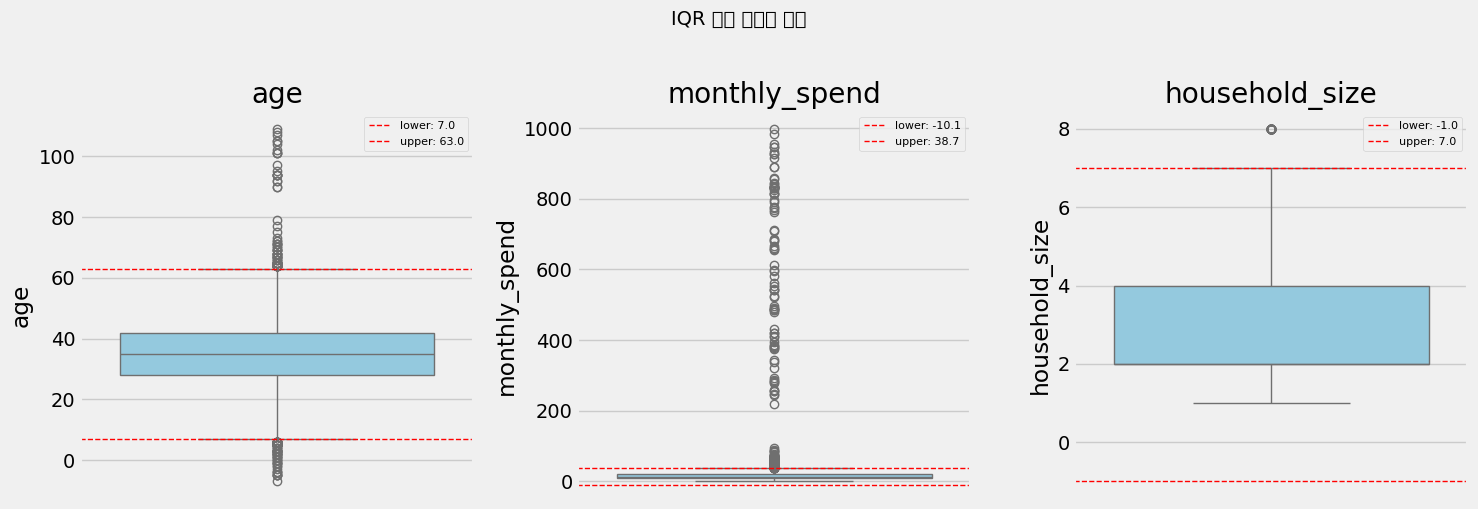

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = train.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    sns.boxplot(y=train[col], ax=ax, color='skyblue')
    ax.axhline(lower, color='red', linestyle='--', linewidth=1, label=f'lower: {lower:.1f}')
    ax.axhline(upper, color='red', linestyle='--', linewidth=1, label=f'upper: {upper:.1f}')
    ax.set_title(f'{col}')
    ax.legend(fontsize=8)

plt.suptitle('IQR 기반 이상치 탐지', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### data encoding

In [40]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
train.columns

Index(['age', 'gender', 'subscription_plan', 'subscription_start_date',
       'monthly_spend', 'primary_device', 'household_size'],
      dtype='object')

In [42]:
# 범주형(문자열) 데이터 컬럼들을 리스트로 지정.
enc_cols = ['gender', 'subscription_plan','subscription_start_date','primary_device']
# 전체 컬럼에서 범주형 컬럼을 제외한 '나머지 컬럼'들을 추출.
normal_cols = list(set(train.columns) - set(enc_cols))
normal_cols

['monthly_spend', 'household_size', 'age']

In [43]:
# 1. 결과의 재현성을 위해 랜덤 시드(Seed)를 초기화
reset_seeds()

# 2. 인코딩 전 원본 train과 test 데이터의 크기(행, 열 개수)를 출력하여 확인
print(f'before: {train.shape} / {test.shape}')

# 3. OneHotEncoder 객체를 생성 (범주형 데이터를 0과 1로 변환하는 도구)
enc = OneHotEncoder()

# [ train 데이터 변환 과정 ]

# 4. train 데이터의 범주형 컬럼들(enc_cols)을 학습(fit)하고 변환(transform).
# .toarray(): 희소 행렬을 일반 배열 형태로 변환
# columns=...: 새롭게 만들어진 컬럼 이름(예: country_Korea, gender_Female 등)을 부여
tmp_tr = pd.DataFrame(
    enc.fit_transform(train[enc_cols]).toarray(),
    columns = enc.get_feature_names_out()
)

# 5. 기존의 수치형 데이터(normal_cols)와 새로 만든 인코딩 데이터(tmp_tr)를 가로(axis=1)로 합침
# .reset_index(drop=True): 인덱스 번호를 초기화하여 두 데이터가 어긋나지 않게 맞춤
enc_tr = pd.concat(
    [train[normal_cols].reset_index(drop=True), tmp_tr.reset_index(drop=True)]
    , axis=1
)

# [ TEST 데이터 변환 과정 ]

# 6. test 데이터는 새로 학습하지 않고, 반드시 train에서 학습된 기준(enc) 그대로 변환(transform)만 수행.
tmp_te = pd.DataFrame(
    enc.transform(test[enc_cols]).toarray(),
    columns = enc.get_feature_names_out()
)

# 7. test 데이터의 수치형 데이터와 인코딩 데이터를 합침
enc_te = pd.concat(
    [test[normal_cols].reset_index(drop=True), tmp_te.reset_index(drop=True)]
    , axis=1
)

# 8. 인코딩 후 늘어난 컬럼 수를 포함한 최종 데이터 크기를 확인
print(f'after: {enc_tr.shape} / {enc_te.shape}')

# 9. 변환이 완료된 train 데이터의 상단 5행을 출력하여 결과를 확인
enc_tr.head()

before: (8240, 7) / (2060, 7)
after: (8240, 1113) / (2060, 1113)


,monthly_spend,household_size,age,gender_Female,gender_Male,gender_Other,gender_Prefer not to say,subscription_plan_Basic,subscription_plan_Premium,subscription_plan_Premium+,...,subscription_start_date_2025-07-29,subscription_start_date_2025-07-30,subscription_start_date_2025-07-31,subscription_start_date_2025-08-01,primary_device_Desktop,primary_device_Gaming Console,primary_device_Laptop,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet
0,41.40,1.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,7.06,2.0,37.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,5.11,3.0,39.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,16.79,3.0,71.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,13.21,1.0,12.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Training

In [44]:
enc_tr.isnull().sum().sum(), enc_te.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [45]:
enc_tr.shape, enc_te.shape

((8240, 1113), (2060, 1113))

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
reset_seeds() # 랜덤 고정

model = DecisionTreeClassifier()  # 모델 생성

print(f'{enc_tr.shape} / {y_tr.shape}')
model.fit(enc_tr, y_tr)

(8240, 1113) / (8240,)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

## Evaluation

In [48]:
reset_seeds()

score_tr = model.score(enc_tr, y_tr) # 학습용 데이터셋으로 평가
score_te = model.score(enc_te, y_te) # 평가용 데이터셋으로 평가

score_tr, score_te

(1.0, 0.7810679611650485)

In [49]:
from sklearn.metrics import (
    roc_curve, auc,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 각 유저가 이탈(Yes)할 확률을 계산
# [:, 1]은 두 번째 컬럼인 '이탈할 확률'만 가져오겠다는 뜻
y_prob = model.predict_proba(enc_te)[:, 1]

# 2. 확률이 0.5보다 크면 이탈(1), 작으면 유지(0)로 분류
y_pred = (y_prob > 0.5).astype(int)

# pos_label='Yes'를 추가하여 'Yes'가 True임을 명시
fpr, tpr, thresholds = roc_curve(y_te, y_prob, pos_label=1)
auc_te = auc(fpr, tpr)
print(f'model AUC: {auc_te}')

model AUC: 0.541025641025641


In [50]:
# 테스트 데이터(enc_te)에 예측 결과를 붙여서 확인
result_Netflix = enc_te.copy()
result_Netflix['churn_probability'] = y_prob  # 이탈 확률
result_Netflix['predicted_churn'] = y_pred    # 이탈 여부 예측 (0 또는 1)

# 모델이 '이탈(1)'로 예측한 회원들만 필터링
predicted_churners = result_Netflix[result_Netflix['predicted_churn'] == 1]

print(f"전체 테스트 회원 수: {len(result_Netflix)}명")
print(f"모델이 예측한 이탈 회원 수: {len(predicted_churners)}명")
predicted_churners.head()

전체 테스트 회원 수: 2060명
모델이 예측한 이탈 회원 수: 268명


,monthly_spend,household_size,age,gender_Female,gender_Male,gender_Other,gender_Prefer not to say,subscription_plan_Basic,subscription_plan_Premium,subscription_plan_Premium+,...,subscription_start_date_2025-07-31,subscription_start_date_2025-08-01,primary_device_Desktop,primary_device_Gaming Console,primary_device_Laptop,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,churn_probability,predicted_churn
1,2.96,2.0,29.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
5,8.65,4.0,31.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
9,35.87,2.0,34.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
33,17.62,3.0,56.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
46,13.03,5.0,42.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1


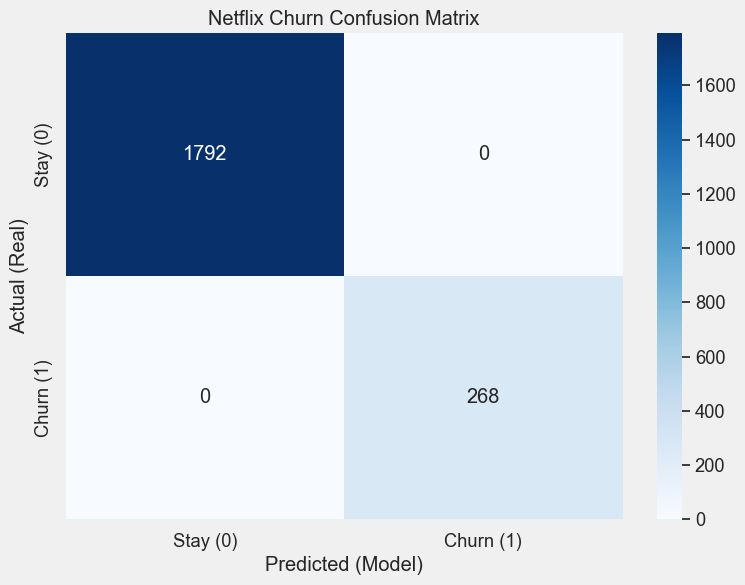

         혼동 행렬(Confusion Matrix) 해석
✅ TN (True Negative)  :  1,792명
   → 유지인데, 모델도 유지로 정확히 예측

❌ FP (False Positive) :      0명
   → 유지인데, 모델이 이탈로 잘못 예측

❌ FN (False Negative) :      0명
   → 실제 이탈인데, 모델이 유지로 잘못 예측

✅ TP (True Positive)  :    268명
   → 실제 이탈인데, 모델도 이탈으로 정확히 예측

📊 파생 지표 요약
  Accuracy  (전체 정확도)     : 1.0000  → 전체 중 맞춘 비율
  Precision (정밀도)          : 1.0000  → Churn 예측 중 실제 Churn 비율
  Recall    (재현율)          : 1.0000  → 실제 Churn 중 맞춘 비율
  F1 Score  (정밀도+재현율)   : 1.0000  → Precision과 Recall의 조화 평균


In [51]:
# 1. 혼동 행렬 데이터 생성
# y_prob: 실제 정답(0, 1), y_pred: 모델의 예측값(0, 1)
cm = confusion_matrix(y_prob, y_pred)

# 2. 그래프 크기 및 스타일 설정
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2) # 글자 크기 조절

# 3. 히트맵(Heatmap) 그리기
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])

# 4. 라벨 및 타이틀 추가
plt.xlabel('Predicted (Model)')
plt.ylabel('Actual (Real)')
plt.title('Netflix Churn Confusion Matrix')
plt.show()

# 5. 혼동 행렬 각 값 추출
tn, fp, fn, tp = cm.ravel()

# 6. 각 숫자의 의미 출력
print("=" * 45)
print("         혼동 행렬(Confusion Matrix) 해석")
print("=" * 45)
print(f"✅ TN (True Negative)  : {tn:>6,}명")
print(f"   → 유지인데, 모델도 유지로 정확히 예측")
print()
print(f"❌ FP (False Positive) : {fp:>6,}명")
print(f"   → 유지인데, 모델이 이탈로 잘못 예측")
print()
print(f"❌ FN (False Negative) : {fn:>6,}명")
print(f"   → 실제 이탈인데, 모델이 유지로 잘못 예측")
print()
print(f"✅ TP (True Positive)  : {tp:>6,}명")
print(f"   → 실제 이탈인데, 모델도 이탈으로 정확히 예측")
print("=" * 45)

# 7. 파생 지표 출력
accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📊 파생 지표 요약")
print("=" * 45)
print(f"  Accuracy  (전체 정확도)     : {accuracy:.4f}  → 전체 중 맞춘 비율")
print(f"  Precision (정밀도)          : {precision:.4f}  → Churn 예측 중 실제 Churn 비율")
print(f"  Recall    (재현율)          : {recall:.4f}  → 실제 Churn 중 맞춘 비율")
print(f"  F1 Score  (정밀도+재현율)   : {f1:.4f}  → Precision과 Recall의 조화 평균")
print("=" * 45)

In [52]:
# column별 중요도
df_feature_importances = pd.DataFrame(
    model.feature_importances_,
    index=enc_tr.columns,
    columns=['importance']
).sort_values(by='importance', ascending=False).reset_index()

# 중요도를 % 형식으로 추가
df_feature_importances['importance_%'] = (
    df_feature_importances['importance'] * 100
).round(2).astype(str) + '%'

df_feature_importances[['index', 'importance_%']]

,index,importance_%
0,monthly_spend,7.03%
1,age,5.43%
2,household_size,3.3%
3,gender_Male,2.16%
4,gender_Female,2.01%
...,...,...
1108,subscription_start_date_2022-12-25,0.0%
1109,subscription_start_date_2025-06-07,0.0%
1110,subscription_start_date_2025-06-06,0.0%
1111,subscription_start_date_2025-06-05,0.0%


In [53]:
args.results.append(
    {
        'model': 'modelV0',
        'score_tr': score_tr,
        'score_te': score_te,
        'auc_te': auc_te,
        'len_features': X_tr.shape[1],
        'feaute_importances': list(df_feature_importances['index'].values[:X_tr.shape[1]]),
        'create_dt': '0327'
    }
)

args.results

[{'model': 'modelV0',
  'score_tr': 1.0,
  'score_te': 0.7810679611650485,
  'auc_te': 0.541025641025641,
  'len_features': 15,
  'feaute_importances': ['monthly_spend',
   'age',
   'household_size',
   'gender_Male',
   'gender_Female',
   'subscription_plan_Premium',
   'primary_device_Laptop',
   'primary_device_Tablet',
   'primary_device_Desktop',
   'primary_device_Mobile',
   'subscription_plan_Standard',
   'primary_device_Gaming Console',
   'subscription_plan_Basic',
   'primary_device_Smart TV',
   'subscription_plan_Premium+'],
  'create_dt': '0327'}]

# Submission

In [54]:
Netflix_results = pd.DataFrame(args.results).sort_values(by=['auc_te'], ascending=False)
Netflix_results

,model,score_tr,score_te,auc_te,len_features,feaute_importances,create_dt
0,modelV0,1.0,0.781068,0.541026,15,"[monthly_spend, age, household_size, gender_Ma...",0327


In [55]:
X_tr.to_csv(args.train_csv, index=False)
X_te.to_csv(args.test_csv, index=False)

# Submission 양식 생성
submission_Netflix = X_te[['user_id']].copy()
submission_Netflix['is_churned'] = 0  # 임시 정답값
submission_Netflix.to_csv(args.default_submission_csv, index=False)

# Save Results

In [56]:
# 1. 모델로 예측
submission_Netflix['is_churned'] = model.predict(enc_te)

# 2. 최종 파일 저장
submission_Netflix.to_csv(args.default_submission_csv, index=False)

print(f"저장 완료: {args.default_submission_csv}")

저장 완료: C:/dev/project/mini_project/SKN27-2nd-2TEAM/models/data/Netflix_submission.csv


In [57]:
import json

# 1. 모델 평가 지표 계산
accuracy = round(accuracy_score(y_te, y_pred), 4)

results = {
    "accuracy":  accuracy,
    "loss":      round(1 - accuracy, 4),  # 오차율 추가
    "precision": round(precision_score(y_te, y_pred), 4),
    "recall":    round(recall_score(y_te, y_pred), 4),
    "f1_score":  round(f1_score(y_te, y_pred), 4)
}

# 2. JSON 파일로 저장
with open(args.save_results, 'w') as file:
    json.dump(results, file, indent=4)

print(f"저장 완료: {args.save_results}")
print(json.dumps(results, indent=4))

저장 완료: C:/dev/project/mini_project/SKN27-2nd-2TEAM/models/data/Netflix_results.json
{
    "accuracy": 0.7811,
    "loss": 0.2189,
    "precision": 0.2276,
    "recall": 0.2,
    "f1_score": 0.2129
}


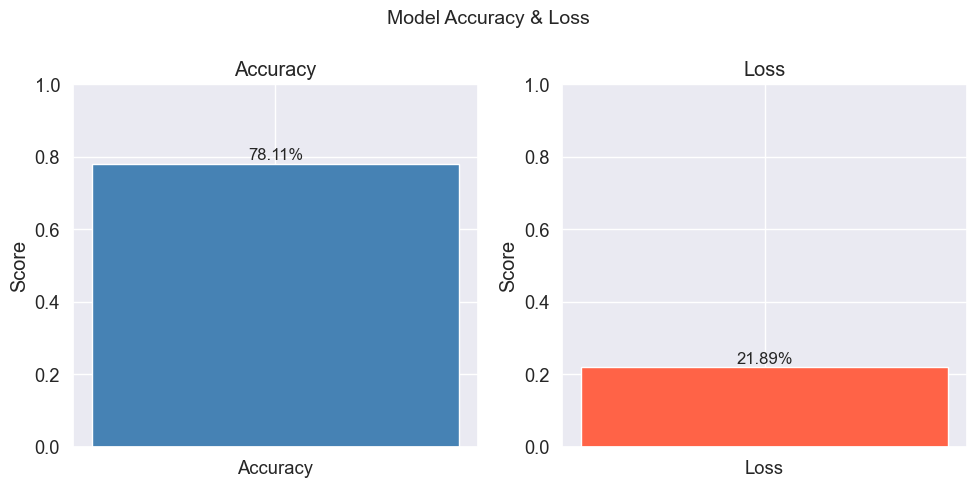

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Accuracy 그래프
axes[0].bar(['Accuracy'], [results['accuracy']], color='steelblue', width=0.4)
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Score')
for bar in axes[0].patches:
axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{results['accuracy']*100:.2f}%", ha='center', fontsize=12)

# Loss 그래프
axes[1].bar(['Loss'], [results['loss']], color='tomato', width=0.4)
axes[1].set_ylim(0, 1)
axes[1].set_title('Loss')
axes[1].set_ylabel('Score')
for bar in axes[1].patches:
axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{results['loss']*100:.2f}%", ha='center', fontsize=12)

plt.suptitle('Model Accuracy & Loss', fontsize=14)
plt.tight_layout()
plt.show()